In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
BATCH_SIZE = 64
IMG_SIZE   = 32
EPOCHS     = 20
LR         = 1e-3
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using: {DEVICE}")

Using: cuda


Transforming the images to feed them to the model:
2 different pipelines for traning data and testing data

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

Loading the train and test folders from the CIFAKE dataset

In [5]:
train_dataset = datasets.ImageFolder(("C:/Users/mouni/Downloads/CIFAKE/train"),transform=train_transform)#path of the train folder needs to be pasted here
test_dataset  = datasets.ImageFolder(("C:/Users/mouni/Downloads/CIFAKE/test"),transform=test_transform)#path of the test folder need to be pasted here

print(f"Classes: {train_dataset.classes}")
print(f"Train images: {len(train_dataset)}")
print(f"Test images : {len(test_dataset)}")

Classes: ['FAKE', 'REAL']
Train images: 100000
Test images : 20000


DataLoader fetches the images in batches according to the BATCH_SIZE and feeds them to the model during traning

In [6]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 1563
Test batches : 313


Convolutional Neural Networks (CNN) model:
Has a input layer , 2 hidden layers and an output layer

In [36]:
Model = nn.Sequential(
    #input layer
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32), 
    nn.ReLU(),
    # 1st hidden layer
    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32), 
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Dropout2d(0.25),

    # 2nd hidden layer
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64), nn.ReLU(),
    #3rd hidden layer
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Dropout2d(0.25),

    # 3rd hidden layer
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128), nn.ReLU(),
    # 4th hidden layer
    nn.Conv2d(128, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128), nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Dropout2d(0.25),

    #output
    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 128),         nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(128, 2),
)

In [38]:
model = Model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

Model parameters: 1,402,914


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

Functions for training for each epoch and testing:

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct    = 0

    for imgs, labels in loader:  # loads the images batch wise of 64 until all the images are processsed for each epoch.
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct    = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs     = model(imgs)
        total_loss += criterion(outputs, labels).item()
        correct    += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

Training starts here and it saves the model with the best accuracy:

In [18]:
import copy

best_acc   = 0.0
best_model = copy.deepcopy(model.state_dict())
os.makedirs("model", exist_ok=True)

print(f"\n{'Epoch':>6} {'T-Loss':>8} {'T-Acc':>7} {'V-Loss':>8} {'V-Acc':>7}")

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    v_loss, v_acc = evaluate(model, test_loader, criterion)
    scheduler.step()

    print(f"{epoch:>6} {t_loss:>8.4f} {t_acc:>6.2%} {v_loss:>8.4f} {v_acc:>6.2%}")

    if v_acc > best_acc:
        best_acc   = v_acc
        best_model = copy.deepcopy(model.state_dict())
        torch.save(best_model, "model/best_model.pth")
        print(f"  saved (best: {best_acc:.2%})")

print(f"\nTraining done. Best accuracy: {best_acc:.2%}")


 Epoch   T-Loss   T-Acc   V-Loss   V-Acc
     1   0.1335 94.99%   0.1241 95.47%
  saved (best: 95.47%)
     2   0.1310 95.10%   0.1153 95.66%
  saved (best: 95.66%)
     3   0.1302 95.16%   0.1110 95.86%
  saved (best: 95.86%)
     4   0.1268 95.20%   0.1259 95.32%
     5   0.1261 95.26%   0.1180 95.62%
     6   0.1274 95.17%   0.1130 95.81%
     7   0.1245 95.34%   0.1229 95.28%
     8   0.1240 95.31%   0.1084 95.94%
  saved (best: 95.94%)
     9   0.1234 95.37%   0.1156 95.50%
    10   0.1240 95.38%   0.1184 95.55%
    11   0.1170 95.58%   0.1268 95.36%
    12   0.1153 95.67%   0.1276 95.33%
    13   0.1146 95.69%   0.1154 95.77%
    14   0.1110 95.84%   0.1228 95.38%
    15   0.1125 95.81%   0.1199 95.47%
    16   0.1122 95.74%   0.1116 95.86%
    17   0.1102 95.84%   0.1124 95.73%
    18   0.1104 95.84%   0.0986 96.33%
  saved (best: 96.33%)
    19   0.1113 95.84%   0.1191 95.64%
    20   0.1095 95.87%   0.1231 95.60%

Training done. Best accuracy: 96.33%


In [20]:
print("for test dataset:")
CLASS_NAMES = test_dataset.classes
print(f"Classes: {CLASS_NAMES}")
print(f"Test images: {len(test_dataset)}")

for test dataset:
Classes: ['FAKE', 'REAL']
Test images: 20000


INFERENCE: to get more detailed output like labels and probabilities

In [21]:
all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(DEVICE)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)[:, 1]  # probability of REAL
        preds   = outputs.argmax(1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print("Inference done")
print(f"Total samples: {len(all_labels)}")

Inference done
Total samples: 20000


In [26]:
accuracy = (all_labels == all_preds).mean()
auroc    = roc_auc_score(all_labels, all_probs)

print("TEST RESULTS")
print(f"  Accuracy : {accuracy:.4f}  ({accuracy:.2%})")
print(f"AUROC : {auroc:.4f}")

print("\nPer-class Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

TEST RESULTS
  Accuracy : 0.9560  (95.60%)
AUROC : 0.9947

Per-class Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.93      0.95     10000
        REAL       0.93      0.99      0.96     10000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



CONFUSION MATRIX: confusion matrox for all the images in test data

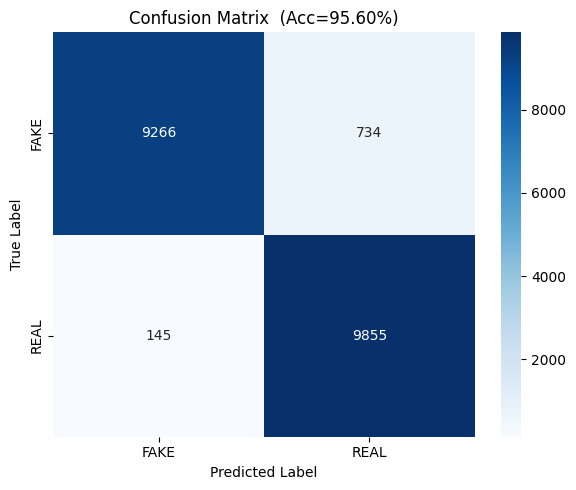

Saved: results/confusion_matrix.png


In [32]:
import os
os.makedirs("results", exist_ok=True)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title(f"Confusion Matrix  (Acc={accuracy:.2%})")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150)
plt.show()
print("Saved: results/confusion_matrix.png")

ROC curve:

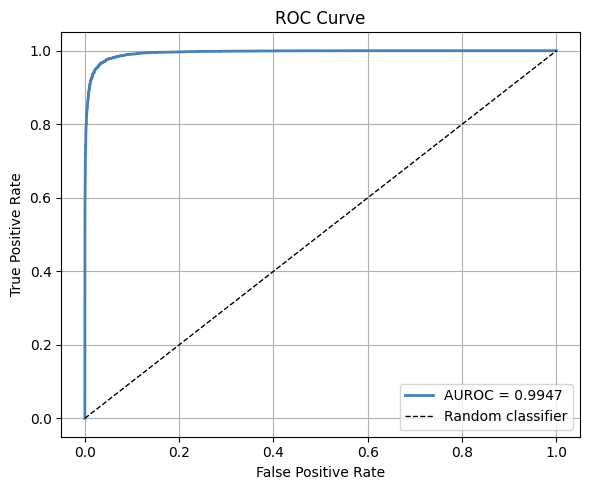

Saved: results/roc_curve.png


In [33]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/roc_curve.png", dpi=150)
plt.show()
print("Saved: results/roc_curve.png")

CONFIDENCE DISTRIBUTION:

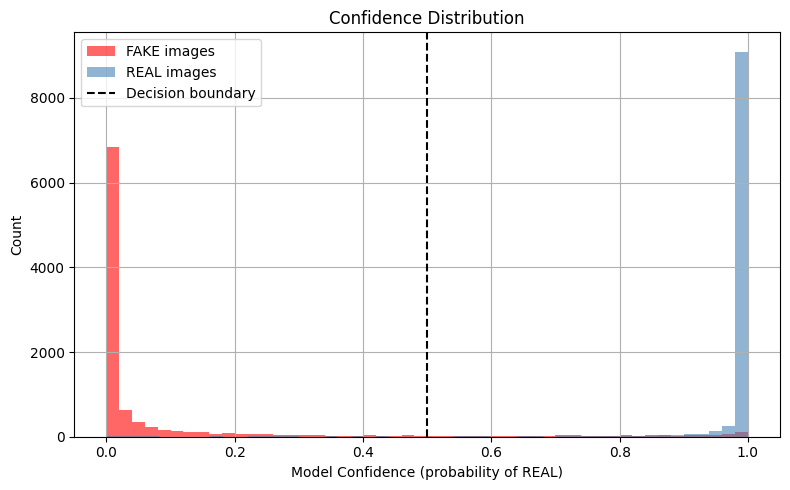

Saved: results/confidence_distribution.png


In [34]:
real_probs = all_probs[all_labels == 1]
fake_probs = all_probs[all_labels == 0]

plt.figure(figsize=(8, 5))
plt.hist(fake_probs, bins=50, alpha=0.6, color="red",       label="FAKE images")
plt.hist(real_probs, bins=50, alpha=0.6, color="steelblue", label="REAL images")
plt.axvline(x=0.5, color="black", linestyle="--", label="Decision boundary")
plt.xlabel("Model Confidence (probability of REAL)")
plt.ylabel("Count")
plt.title("Confidence Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/confidence_distribution.png", dpi=150)
plt.show()
print("Saved: results/confidence_distribution.png")